## Exercise 3 (Matrix Transpose)

### a) `transpose.cc`

## Machine information

| Property | Machine |
|---|---|
| CPU model | Intel Core i5-10300H (Comet Lake-H, 14 nm) |
| Cores / threads | 4 / 8, SMT enabled |
| Base clock | 2.5 GHz |
| Turbo clock | up to 4.5 GHz, 1-core |
| L1 cache | 32 KB instruction + 32 KB data per core, 8-way |
| L2 cache | 256 KB per core, 4-way |
| L3 cache | 8 MB shared, 16-way |
| Cache line size | 64 B |
| DRAM | 16 GB DDR4-2933, dual channel |
| Theoretical peak memory bandwidth | 46.9 GB/s |
| Vector ISA | SSE, SSE2, SSE4.1, SSE4.2, AVX, AVX2, FMA |
| Max SIMD width | 256-bit, 4 doubles per vector |


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_file = Path("results/transpose_results.csv")
df = pd.read_csv(csv_file)
df.head()


,strategy,N,block_size,repetitions,runtime_ms,bandwidth_GBps,checksum
0,consecutive-write,256,0,512,0.212156,4.942,25296384.0
1,strided-write,256,0,256,0.443066,2.367,25296384.0
2,blocked-consecutive-write,256,4,1024,0.178873,5.862,25296384.0
3,blocked-strided-write,256,4,1024,0.119861,8.748,25296384.0
4,blocked-consecutive-write,256,8,2048,0.084710,12.378,25296384.0


## Runtime table


In [7]:
runtime_table = df[["strategy", "N", "block_size", "runtime_ms"]].copy()
runtime_table.sort_values(["N", "strategy", "block_size"])


,strategy,N,block_size,runtime_ms
2,blocked-consecutive-write,256,4,0.178873
4,blocked-consecutive-write,256,8,0.084710
6,blocked-consecutive-write,256,16,0.043931
8,blocked-consecutive-write,256,24,0.049189
10,blocked-consecutive-write,256,32,0.052019
...,...,...,...,...
75,blocked-strided-write,4096,32,68.053000
77,blocked-strided-write,4096,64,76.331000
79,blocked-strided-write,4096,128,71.846500
64,consecutive-write,4096,0,328.617000


In [8]:
best_runtime = (
    df.sort_values("runtime_ms")
      .groupby("N", as_index=False)
      .first()[["N", "strategy", "block_size", "runtime_ms"]]
)
best_runtime


,N,strategy,block_size,runtime_ms
0,256,blocked-consecutive-write,16,0.043931
1,512,blocked-consecutive-write,8,0.219965
2,1024,blocked-consecutive-write,32,1.628062
3,2048,blocked-strided-write,8,9.086812
4,4096,blocked-consecutive-write,32,43.683250


## Runtime plots


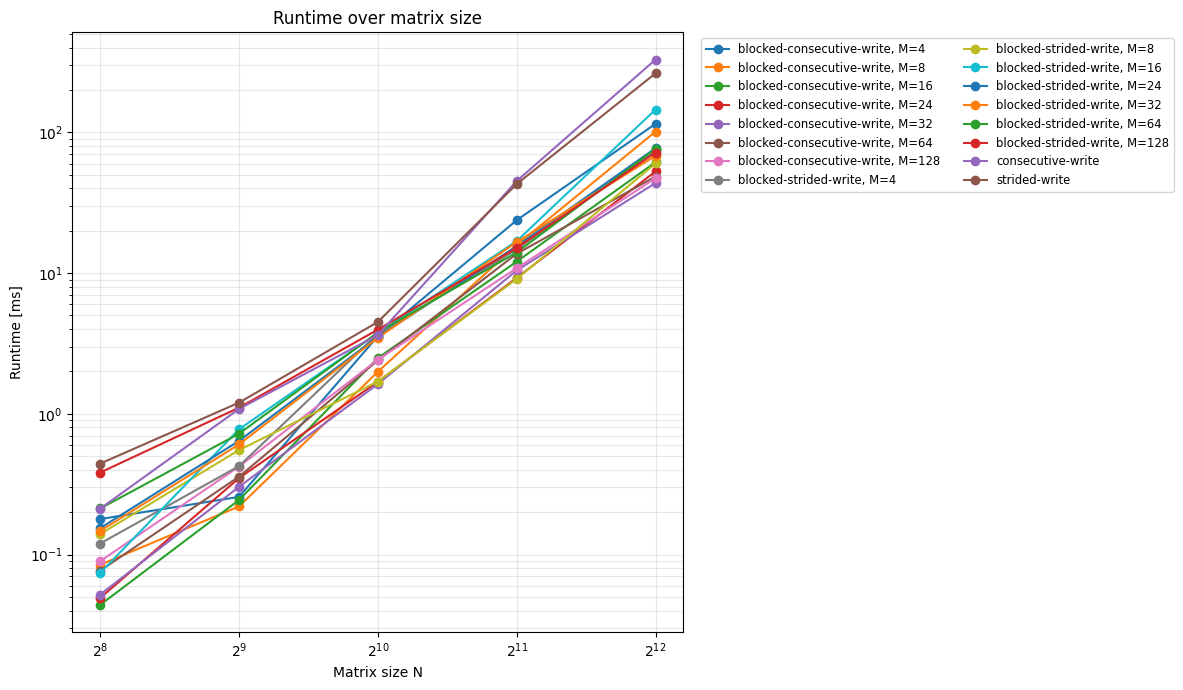

In [9]:
fig, ax = plt.subplots(figsize=(12, 7))

for (strategy, block_size), group in df.groupby(["strategy", "block_size"]):
    label = strategy if block_size == 0 else f"{strategy}, M={block_size}"
    group = group.sort_values("N")
    ax.plot(group["N"], group["runtime_ms"], marker="o", linewidth=1.5, label=label)

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Matrix size N")
ax.set_ylabel("Runtime [ms]")
ax.set_title("Runtime over matrix size")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize="small", ncols=2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig("results/transpose_runtime_by_size.png", dpi=180, bbox_inches="tight")
plt.show()


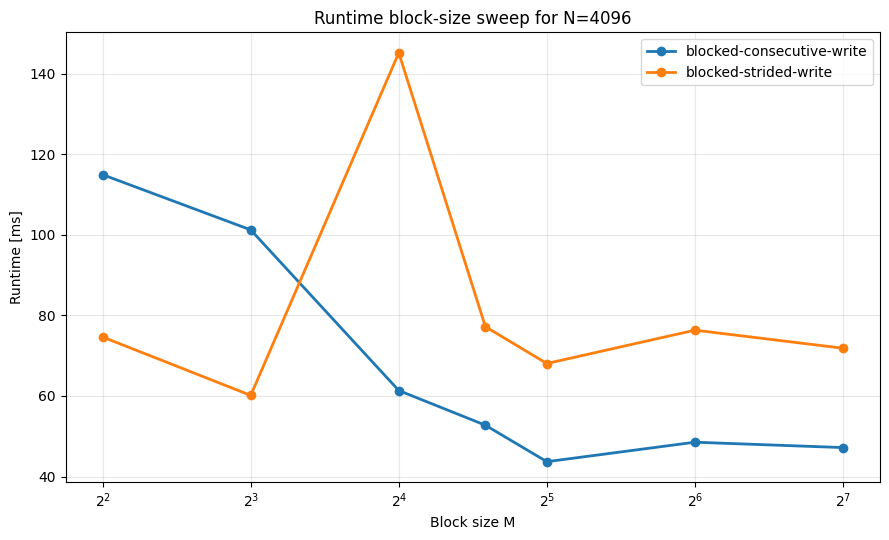

In [10]:
largest_n = df["N"].max()
blocked = df[(df["N"] == largest_n) & (df["block_size"] > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 5.5))

for strategy, group in blocked.groupby("strategy"):
    group = group.sort_values("block_size")
    ax.plot(group["block_size"], group["runtime_ms"], marker="o", linewidth=2, label=strategy)

ax.set_xscale("log", base=2)
ax.set_xlabel("Block size M")
ax.set_ylabel("Runtime [ms]")
ax.set_title(f"Runtime block-size sweep for N={largest_n}")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("results/transpose_runtime_block_size_sweep.png", dpi=180, bbox_inches="tight")
plt.show()


## Remarks

### b) vectorized version